# EmporiUm Sales Territory Analysis

**Analyst:** Onur Karaer  
**Territory Manager:** Erbayne Middleton  
**Region:** Northeast  
**Territories:** Maine — Stores 818, 819, 820, 821, 822, 823  
**Cities:** Bangor, Bar Harbor, Kennebunkport, Lewiston, Orono, South Portland  
**Data Period:** 2022–2025  

## Project Description
This notebook analyzes in-store sales performance for the territories assigned 
to Erbayne Middleton in the Northeast region. The analysis covers monthly revenue 
trends, store performance rankings, top customers, and product category insights, 
concluding with a marketing recommendation for the next quarter.

In [163]:
import pandas as pd
import matplotlib.pyplot as plt


In [164]:
store_sales = pd.read_csv('StoreSales (1).csv')
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [165]:
store_detail = pd.read_csv('StoreDetail (1).csv')
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [166]:
products = pd.read_csv('Products (3).csv')
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [167]:
product_categories = pd.read_csv('ProductCategories (1).csv')
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [168]:
customer_list = pd.read_csv('customer_list (1).csv', sep='|') #Columns are seperated with bar instead of commas in this file
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [169]:
print(store_sales.head(3))
print(store_detail.head(3))
print(products.head(3))
print(product_categories.head(3))
print(customer_list.head(3))

  Transaction Date  Store ID  RewardsID  Prod Num  Sale Amount
0         1/1/2022       702        NaN  105349-M          8.0
1         1/1/2022       704        NaN  105350-T        144.0
2         1/1/2022       705        NaN  105351-M         44.0
  Store Location     State  Store ID Territory Manager Region  Region Director
0         Aurora  Colorado       701          Jim Heck   West  Cassie Chambers
1       Berthoud  Colorado       702          Jim Heck   West  Cassie Chambers
2        Boulder  Colorado       703          Jim Heck   West  Cassie Chambers
    Prod Num                        Product  CategoryID SubcategoryID
0  105248-IT               TCL NXTPAPER 10s         120       120-tab
1  105249-IT  Dell Latitude 7320 Detachable         120       120-tab
2  105250-IT                     Realme Pad         120       120-tab
   CategoryID                  Category SubcategoryID        Subcategory
0         120  Technology & Accessories       120-tab            Tablets
1     

# Core Marketing Analysis

The following analysis addresses key questions from the marketing manager 
for the two sales territories assigned to Erbayne Middleton in the 
Northeast region (Maine). Analysis covers stores 818–823 across 
Bangor, Bar Harbor, Kennebunkport, Lewiston, Orono, and South Portland.

In [170]:
store_detail[store_detail['Territory Manager'] == 'Erbayne Middleton'] #Checking the stores belong to me.

,Store Location,State,Store ID,Territory Manager,Region,Region Director
37,Bangor,Maine,818,Erbayne Middleton,Northeast,Michael Jarvis
38,Bar Harbor,Maine,819,Erbayne Middleton,Northeast,Michael Jarvis
39,Kennebunkport,Maine,820,Erbayne Middleton,Northeast,Michael Jarvis
40,Lewiston,Maine,821,Erbayne Middleton,Northeast,Michael Jarvis
41,Orono,Maine,822,Erbayne Middleton,Northeast,Michael Jarvis
42,South Portland,Maine,823,Erbayne Middleton,Northeast,Michael Jarvis


In [171]:
store_detail[store_detail['Region'] == 'Northeast']['Territory Manager'].unique() #Checking the other managers in the Northeast region.

<StringArray>
['Erbayne Middleton', 'Shruti Reddy', 'Bo Heap', 'Miami Vue']
Length: 4, dtype: str

In [172]:
store_detail[store_detail['Region'] == 'Northeast'].groupby('Territory Manager')['Store ID'].count() #Checking how many stores other managers have. I will pick
                                                                                                    #Shruti Reddy as a comparision point since numbers of stores and
                                                                                                    #the size of the state is the closest to me.

Territory Manager
Bo Heap              18
Erbayne Middleton     6
Miami Vue            16
Shruti Reddy          9
Name: Store ID, dtype: int64

## Territory Selection

This analysis compares two sales territories in the Northeast region:

- **Territory 1:** Erbayne Middleton: Maine (Stores 818–823)
- **Territory 2:** Shruti Reddy: Selected as comparison territory due to similar store count (9 stores) within the same Northeast region

Both territories will be analyzed side by side throughout this report.

## Question 1: Territory Managers and Store Information

Who are the territory managers for the assigned sales territories? 
What are the store IDs and cities for the stores in each territory?

In [173]:
# Filter stores for both territories
erbayne_stores = store_detail[store_detail['Territory Manager'] == 'Erbayne Middleton']
shruti_stores = store_detail[store_detail['Territory Manager'] == 'Shruti Reddy']

# Display store information for each territory. I only selected the columns below to display. Micheal Jarvis is the region director for all the stores that I am analyzing.
print("Territory 1: Erbayne Middleton")
print(erbayne_stores[['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region']])

print("Territory 2: Shruti Reddy")
print(shruti_stores[['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region']])

Territory 1: Erbayne Middleton
    Store ID  Store Location  State  Territory Manager     Region
37       818          Bangor  Maine  Erbayne Middleton  Northeast
38       819      Bar Harbor  Maine  Erbayne Middleton  Northeast
39       820   Kennebunkport  Maine  Erbayne Middleton  Northeast
40       821        Lewiston  Maine  Erbayne Middleton  Northeast
41       822           Orono  Maine  Erbayne Middleton  Northeast
42       823  South Portland  Maine  Erbayne Middleton  Northeast
Territory 2: Shruti Reddy
    Store ID       Store Location     State Territory Manager     Region
43       731            Annapolis  Maryland      Shruti Reddy  Northeast
44       732           Back River  Maryland      Shruti Reddy  Northeast
45       733            Baltimore  Maryland      Shruti Reddy  Northeast
46       734           Germantown  Maryland      Shruti Reddy  Northeast
47       735               Howard  Maryland      Shruti Reddy  Northeast
48       736        North Harford  Maryland

## Question 2: Monthly Total Revenue by Territory

What is the monthly total revenue for in-store sales in each of the 
two sales territories over the full period covered by the data?

In [174]:
# Filter sales for each territory
erbayne_sales = store_sales[store_sales['Store ID'].isin(erbayne_stores['Store ID'])] #.isin() works like WHERE Store ID IN (..) in SQL
shruti_sales = store_sales[store_sales['Store ID'].isin(shruti_stores['Store ID'])]     #So i only pulled the sales data from stores that i am assigned to.

#I previously got SettingWithCopyWarning when i tried to add columns as in the following steps
#I need to copy the filtered dataframe above to create a new data frame. So I can add new columns on that.
erbayne_sales = erbayne_sales.copy()
shruti_sales = shruti_sales.copy()

# Converted Transaction Date to datetime. Because the time information in the original sales file recorded as STR.
erbayne_sales['Transaction Date'] = pd.to_datetime(erbayne_sales['Transaction Date'])
shruti_sales['Transaction Date'] = pd.to_datetime(shruti_sales['Transaction Date'])

# Create Year-Month column. I excluded day information. I will do my analyze based on MM-YYYY information.
erbayne_sales['YearMonth'] = erbayne_sales['Transaction Date'].dt.to_period('M')
shruti_sales['YearMonth'] = shruti_sales['Transaction Date'].dt.to_period('M')

# Group by YearMonth and sum revenue
erbayne_monthly = erbayne_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
shruti_monthly = shruti_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()

erbayne_monthly.columns = ['YearMonth', 'Total Revenue']
shruti_monthly.columns = ['YearMonth', 'Total Revenue']

print("Territory 1: Erbayne Middleton - Monthly Revenue")
print(erbayne_monthly)

print("Territory 2: Shruti Reddy - Monthly Revenue")
print(shruti_monthly)

Territory 1: Erbayne Middleton - Monthly Revenue
   YearMonth  Total Revenue
0    2022-01       15700.31
1    2022-02       21008.29
2    2022-03       23173.23
3    2022-04       20169.19
4    2022-05       22631.11
5    2022-06       31573.93
6    2022-07       19371.11
7    2022-08       27979.07
8    2022-09       27393.30
9    2022-10       24947.09
10   2022-11       19783.08
11   2022-12       25345.23
12   2023-01       41331.95
13   2023-02       37650.30
14   2023-03       36162.92
15   2023-04       35875.41
16   2023-05       26201.22
17   2023-06       30183.66
18   2023-07       44731.17
19   2023-08       42202.08
20   2023-09       44862.59
21   2023-10       34905.29
22   2023-11       35428.88
23   2023-12       41279.32
24   2024-01       43881.68
25   2024-02       31494.48
26   2024-03       36311.69
27   2024-04       25764.94
28   2024-05       31426.20
29   2024-06       43488.63
30   2024-07       42202.08
31   2024-08       46505.54
32   2024-09       33262.34

In [175]:
erbayne_sales['Year'] = erbayne_sales['Transaction Date'].dt.year #Revenue per year from Erbayne's stores
erbayne_yearly = erbayne_sales.groupby('Year')['Sale Amount'].sum().reset_index()
erbayne_yearly.columns = ['Year', 'Total Revenue']
print('Erbayne Yearly Revenue')
print(erbayne_yearly)

shruti_sales['Year'] = shruti_sales['Transaction Date'].dt.year #Revenue per year from Shruti's stores
shruti_yearly = shruti_sales.groupby('Year')['Sale Amount'].sum().reset_index()
shruti_yearly.columns = ['Year', 'Total Revenue']
print('Shruti Yearly Revenue')
print(shruti_yearly)

Erbayne Yearly Revenue
   Year  Total Revenue
0  2022      279074.94
1  2023      450814.79
2  2024      452377.73
3  2025      694982.29
Shruti Yearly Revenue
   Year  Total Revenue
0  2022     2409967.70
1  2023     2813693.20
2  2024     2821691.59
3  2025     3406262.60


In [176]:
# Year over year growth for Erbayne
print("Erbayne Middleton - Year over Year Growth")
print(f"2022 to 2023: %{((erbayne_yearly.iloc[1]['Total Revenue'] - erbayne_yearly.iloc[0]['Total Revenue']) / erbayne_yearly.iloc[0]['Total Revenue'] * 100):.1f}")
print(f"2023 to 2024: %{((erbayne_yearly.iloc[2]['Total Revenue'] - erbayne_yearly.iloc[1]['Total Revenue']) / erbayne_yearly.iloc[1]['Total Revenue'] * 100):.1f}")
print(f"2024 to 2025: %{((erbayne_yearly.iloc[3]['Total Revenue'] - erbayne_yearly.iloc[2]['Total Revenue']) / erbayne_yearly.iloc[2]['Total Revenue'] * 100):.1f}")
print(f"2022 to 2025: %{((erbayne_yearly.iloc[3]['Total Revenue'] - erbayne_yearly.iloc[0]['Total Revenue']) / erbayne_yearly.iloc[0]['Total Revenue'] * 100):.1f}")

print()

# Year over year growth for Shruti
print("Shruti Reddy - Year over Year Growth")
print(f"2022 to 2023: %{((shruti_yearly.iloc[1]['Total Revenue'] - shruti_yearly.iloc[0]['Total Revenue']) / shruti_yearly.iloc[0]['Total Revenue'] * 100):.1f}")
print(f"2023 to 2024: %{((shruti_yearly.iloc[2]['Total Revenue'] - shruti_yearly.iloc[1]['Total Revenue']) / shruti_yearly.iloc[1]['Total Revenue'] * 100):.1f}")
print(f"2024 to 2025: %{((shruti_yearly.iloc[3]['Total Revenue'] - shruti_yearly.iloc[2]['Total Revenue']) / shruti_yearly.iloc[2]['Total Revenue'] * 100):.1f}")
print(f"2022 to 2025: %{((shruti_yearly.iloc[3]['Total Revenue'] - shruti_yearly.iloc[0]['Total Revenue']) / shruti_yearly.iloc[0]['Total Revenue'] * 100):.1f}")

Erbayne Middleton - Year over Year Growth
2022 to 2023: %61.5
2023 to 2024: %0.3
2024 to 2025: %53.6
2022 to 2025: %149.0

Shruti Reddy - Year over Year Growth
2022 to 2023: %16.8
2023 to 2024: %0.3
2024 to 2025: %20.7
2022 to 2025: %41.3


- Maryland stores are significantly generating more revenue compared to Maine stores almost 10x in 2022 and around 5x in 2025.
- This difference cannot be explained by store count alone. Maine has 6 stores, Maryland has 9.
- The likely explanation is the population size and income levels of the cities where these stores are located.
- Also the gap between the territories is closing. I want to see if we opened up new stores or closed existing ones.
- Below, I tested whether my arguments are true or false

In [177]:
# Total population for each territory (2024 US Census estimates). I got help from Claude AI researching the populations in my assisgned territories.!!!
erbayne_population = {'Territory': 'Erbayne Middleton', 'State': 'Maine', 'Total Population': 117775}
shruti_population = {'Territory': 'Shruti Reddy', 'State': 'Maryland', 'Total Population': 1160968}
#Population Data:** U.S. Census Bureau, 2024 American Community Survey (ACS) 5-Year Estimates
#Developed with assistance from Claude (Anthropic), claude.ai


# Revenue per capita


erbayne_rpc = erbayne_total_rev / erbayne_population['Total Population']
shruti_rpc = shruti_total_rev / shruti_population['Total Population']

print("Population & Revenue Per Capita Comparison")
print(f"Erbayne Middleton (Maine):")
print(f"Total Population:{erbayne_population['Total Population']:,}")
print(f"Total Revenue: ${erbayne_total_rev:,.2f}")
print(f"Revenue Per Capita:${erbayne_rpc:.2f}")

print(f"Shruti Reddy (Maryland):")
print(f"Total Population: {shruti_population['Total Population']:,}")
print(f"Total Revenue: ${shruti_total_rev:,.2f}")
print(f"Revenue Per Capita: ${shruti_rpc:.2f}")

Population & Revenue Per Capita Comparison
Erbayne Middleton (Maine):
Total Population:117,775
Total Revenue: $1,877,249.75
Revenue Per Capita:$15.94
Shruti Reddy (Maryland):
Total Population: 1,160,968
Total Revenue: $11,451,615.09
Revenue Per Capita: $9.86


- Population Data:** U.S. Census Bureau, 2024 American Community Survey (ACS) 5-Year Estimates
- Developed with assistance from Claude (Anthropic), claude.ai

- The revenue difference between the two territories is mainly driven by population size. The larger the market, the higher the total revenue.
- However, income level is **not** the source of this difference. Maine's revenue per capita is actually **higher** than Maryland's, suggesting stronger individual customer engagement in Erbayne's territory despite the smaller population.

In [178]:
print(erbayne_sales.groupby('Store ID')['YearMonth'].nunique()) #Checking if we have recorded sales from these stores for 48 months.
print(shruti_sales.groupby('Store ID')['YearMonth'].nunique())

Store ID
818    48
819    48
820    48
821    48
822    48
823    48
Name: YearMonth, dtype: int64
Store ID
731    48
732    48
733    48
734    48
735    48
736    48
737    48
738    48
739    48
Name: YearMonth, dtype: int64


- **Store Activity**

- EmporiUm haven't opened up new stores or closed down the existing stores in our territories. 
- So, the closing revenue gap between the territories is not based on the store numbers.

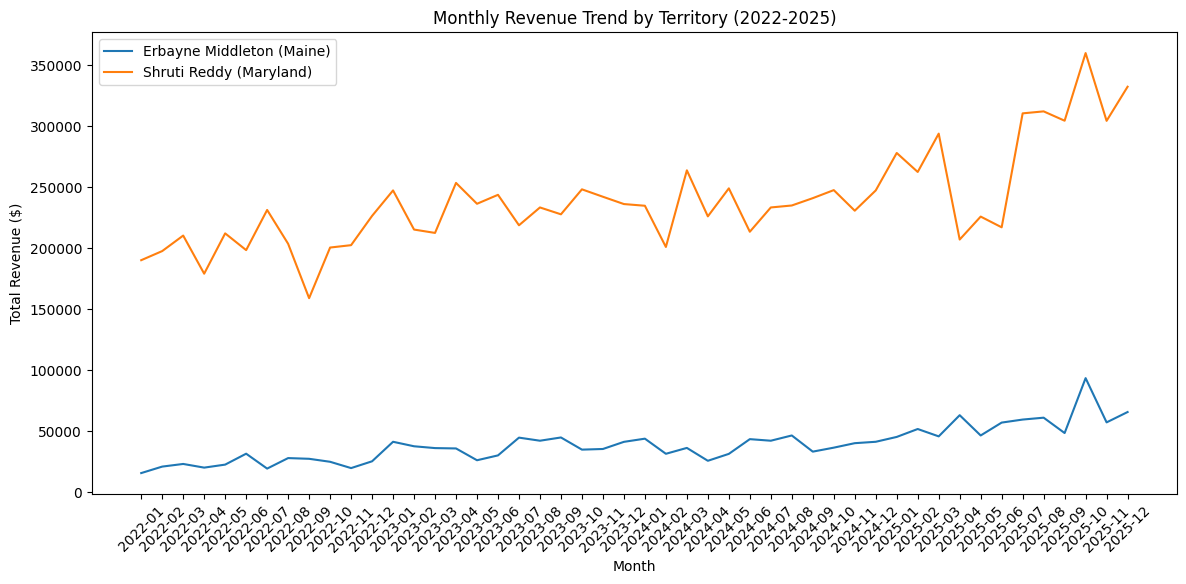

In [179]:
plt.figure(figsize=(14, 6))

plt.plot(erbayne_monthly['YearMonth'].astype(str),erbayne_monthly['Total Revenue'],label='Erbayne Middleton (Maine)')
plt.plot(shruti_monthly['YearMonth'].astype(str),shruti_monthly['Total Revenue'],label='Shruti Reddy (Maryland)')

plt.title('Monthly Revenue Trend by Territory (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

- Both stores are showing an **upwards** trend. 
- The **dips** in August 2022 and March-May 2025 in Maryland should be analayzed.
- The **peaks** in October 2025 in both stores also should be analyzed
- Maine's **revenue per capita is higher** than Maryland's, meaning stronger individual customer engagement despite the smaller market size.
- Maine grew **149%** from 2022 to 2025, while Maryland grew only **41%** Maine is expanding at a significantly faster rate.
- The **revenue gap is closing**  Maine was 10x smaller than Maryland in 2022, but only 5x smaller by 2025.

## Question 3: Store Performance Ranking

How would you rank the sales performance of each store in each sales territory? 
Which are the top-performing stores?

In [180]:
# Total revenue per store
erbayne_store_rev = erbayne_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
shruti_store_rev = shruti_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()

# Add store names
erbayne_store_rev = erbayne_store_rev.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
shruti_store_rev = shruti_store_rev.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')

# Rank by revenue
erbayne_store_rev = erbayne_store_rev.sort_values('Sale Amount', ascending=False)
shruti_store_rev = shruti_store_rev.sort_values('Sale Amount', ascending=False)

print("Erbayne Middleton - Store Rankings")
print(erbayne_store_rev[['Store Location', 'Sale Amount']])

print("Shruti Reddy - Store Rankings")
print(shruti_store_rev[['Store Location', 'Sale Amount']])

Erbayne Middleton - Store Rankings
   Store Location  Sale Amount
5  South Portland    332611.76
4           Orono    330505.47
2   Kennebunkport    321998.55
3        Lewiston    303761.91
0          Bangor    300919.98
1      Bar Harbor    287452.08
Shruti Reddy - Store Rankings
        Store Location  Sale Amount
5        North Harford   8708119.00
3           Germantown    584675.92
6            Parkville    320441.24
4               Howard    319394.58
8              Ridgely    318511.04
2            Baltimore    310099.90
1           Back River    303433.61
7  Queen Anne's County    298074.49
0            Annapolis    288865.31


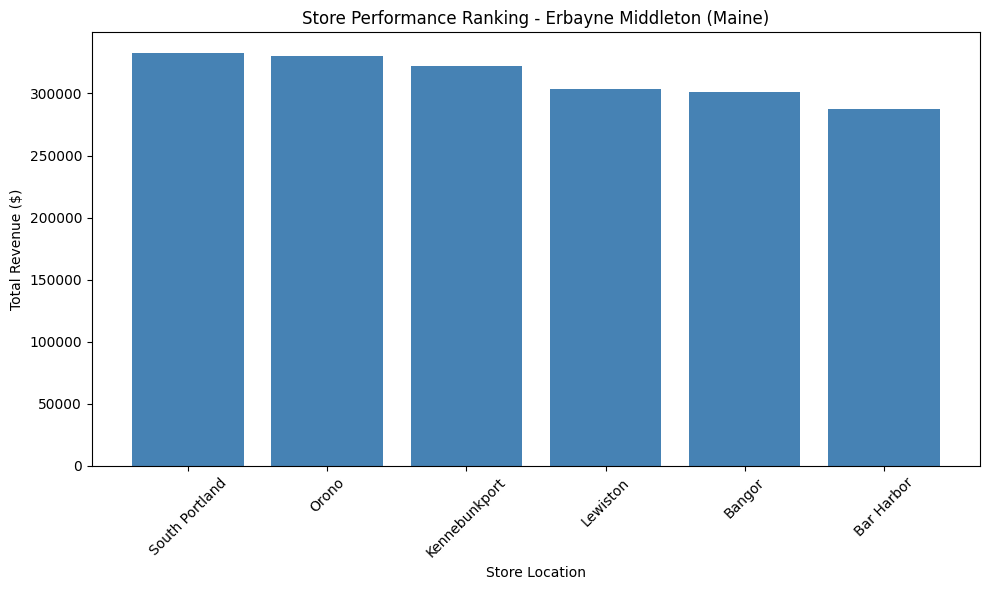

In [181]:
#Bar graph for Erbayne's store performance ranking
plt.figure(figsize=(10, 6))

plt.bar(erbayne_store_rev['Store Location'], erbayne_store_rev['Sale Amount'], color='steelblue')

plt.title('Store Performance Ranking - Erbayne Middleton (Maine)')
plt.xlabel('Store Location')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

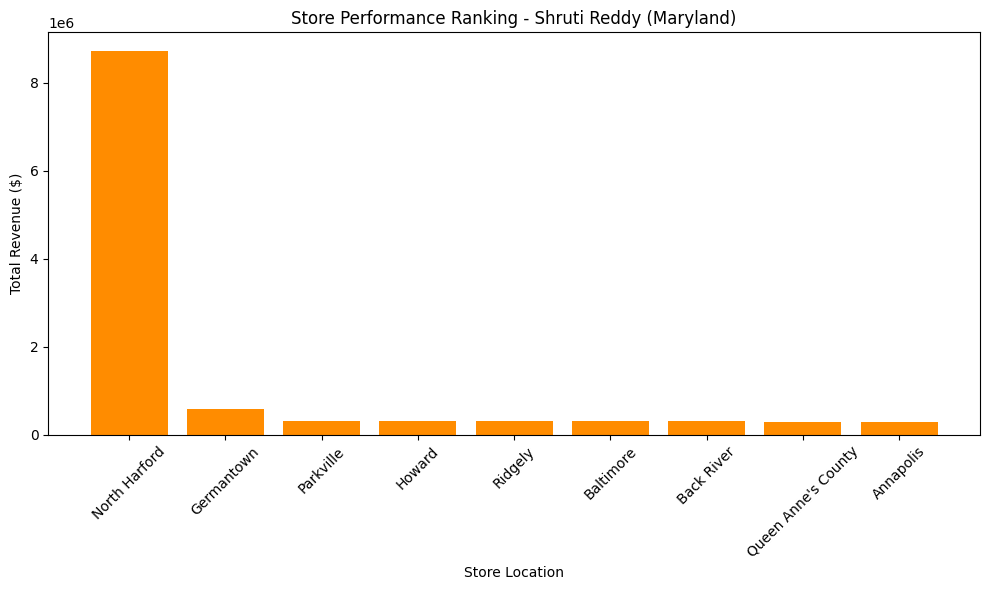

In [182]:
#Bar chart for Shruti's store performance ranking
plt.figure(figsize=(10, 6))

plt.bar(shruti_store_rev['Store Location'], shruti_store_rev['Sale Amount'], color='darkorange')

plt.title('Store Performance Ranking - Shruti Reddy (Maryland)')
plt.xlabel('Store Location')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- **North Harford** dominates Shruti's territory with $8.7M total revenue, 
dwarfing all other stores. This is driven by an unusually high transaction count 
(~1,448/month vs ~46/month average) which warrants further investigation.
- Excluding North Harford, Maryland stores perform similarly to Maine stores 
in the $288K-$584K range.
- Erbayne's Maine territory shows a **balanced store performance** all 6 stores fall within a narrow $287K-$332K range, 
suggesting consistent customer traffic across all locations.

- **North Harford** stands out in Maryland territory with $8.7M total revenue.
- This seem like the biggest revenue difference between territories.
- Why this store is generating much larger revenues compare to others? I need to analyze!
- In Erbayne's territory, stores are relatively **balanced** in performance. Top store South Portland ($332K) and bottom store Bar Harbor ($287K) are close in revenue.


In [183]:
#Trying to see what is going on in North Harford
north_harford_sales = shruti_sales[shruti_sales['Store ID'] == 736]
print(north_harford_sales['Sale Amount'].describe())
print(north_harford_sales.sort_values('Sale Amount', ascending=False).head(10))

#I checked the overall data in all stores in my territories.
print(shruti_sales.groupby('Store ID')['Sale Amount'].describe())
print(erbayne_sales.groupby('Store ID')['Sale Amount'].describe())

print(shruti_sales.groupby('Store ID').size()/48)
print(erbayne_sales.groupby('Store ID').size()/48)

count    69530.000000
mean       125.242615
std        265.532395
min          2.400000
25%         15.350000
50%         28.880000
75%        108.330000
max       1763.700000
Name: Sale Amount, dtype: float64
       Transaction Date  Store ID  RewardsID   Prod Num  Sale Amount  \
213935       2025-01-11       736        NaN  105341-IT       1763.7   
127941       2023-12-08       736      371.0  105341-IT       1763.7   
131904       2023-12-26       736      479.0  105341-IT       1763.7   
28492        2022-07-06       736      145.0  105341-IT       1763.7   
216452       2025-01-19       736        NaN  105341-IT       1763.7   
221618       2025-02-04       736        NaN  105341-IT       1763.7   
29535        2022-07-13       736        NaN  105341-IT       1763.7   
28645        2022-07-07       736        NaN  105341-IT       1763.7   
56167        2023-01-02       736        NaN  105341-IT       1763.7   
233218       2025-03-13       736        NaN  105341-IT       1763.7  

In [184]:
#Checking if there are duplicate records for North Harford
print(north_harford_sales.duplicated().sum())

0


- I checked the summary statistics for all stores. 
- I checked if there are duplicates for North Harford but there are none.
- One data got my attention. All the stores are generating appx. 45 transaction per month.
- Only Germantown (Store 734) in Maryland is generating 90 transaction per month.
- But North Harford is generating appx. **1450** transaction per month!! 

## Question 4
Comparing the customer ID from the customer list data with the rewards ID from the sales data,
who were the top customers in each sales territory?

In [185]:
#Created a new dataframe with customerIDs matched with RewardIDs. This DF will only include customers with RewardsID
merged_customer = pd.merge(customer_list, store_sales, left_on='cust_id', right_on='RewardsID')


# Filter for our territories only
erbayne_customers = merged_customer[merged_customer['Store ID'].isin(erbayne_stores['Store ID'])]
shruti_customers = merged_customer[merged_customer['Store ID'].isin(shruti_stores['Store ID'])]
print(erbayne_customers.head())
print(shruti_customers.head())

# Top customers by total spend in each territory
erbayne_top = erbayne_customers.groupby(['cust_id', 'name'])['Sale Amount'].sum().reset_index()
erbayne_top = erbayne_top.sort_values('Sale Amount', ascending=False).head(10)

shruti_top = shruti_customers.groupby(['cust_id', 'name'])['Sale Amount'].sum().reset_index()
shruti_top = shruti_top.sort_values('Sale Amount', ascending=False).head(10)

print("Top 10 Customers - Erbayne Middleton(Maine)")
print(erbayne_top.to_string(index=False))

print("Top 10 Customers - Shruti Reddy (Maryland)")
print(shruti_top.to_string(index=False))

     cust_id        date      time       name                      email  \
35         1  2023-03-15  08:45:12     Rachel  rachel@centralperk.coffee   
61         1  2023-03-15  08:45:12     Rachel  rachel@centralperk.coffee   
74         2  2023-05-22  12:30:45  R. Geller   rossg@centralperk.coffee   
79         2  2023-05-22  12:30:45  R. Geller   rossg@centralperk.coffee   
113        2  2023-05-22  12:30:45  R. Geller   rossg@centralperk.coffee   

            phone sms-opt-out  Transaction Date  Store ID  RewardsID  \
35   212-555-1001            N       10/13/2024       819        1.0   
61   212-555-1001            N       11/13/2025       819        1.0   
74   212-555-1002            N         3/1/2023       818        2.0   
79   212-555-1002            N        7/13/2023       818        2.0   
113  212-555-1002            N        7/30/2025       821        2.0   

      Prod Num  Sale Amount  
35    105659-A        48.00  
61   105262-IT       603.50  
74    105386-M      

- Only customers with a **RewardsID** are included in this analysis, non-rewards customers are excluded since they cannot be matched to the customer list.
- **Erbayne (Maine):** Top customer is Rosita with $3,637 total spend. 
Top 10 customers are relatively close in spending, ranging from $2,112 to $3,637.
- **Shruti (Maryland):** Top customer is Cole Brown with $7,602 total spend, significantly higher than Maine's top customer, consistent with the larger market size.
- Interestingly, **Trent Lane (cust_id 99)** appears in both territories' top 10, 
suggesting a customer who shops across multiple locations.

## Question 5: Transactions and Revenue by Product Category

What is the number of transactions per month by product category in each assigned territory? 
What is total sales revenue per month by category? What might this tell us about the most 
popular products, and where could there be opportunity for growth?

In [186]:
# Merge sales with products and categories
erbayne_products = erbayne_sales.merge(products, on='Prod Num')
erbayne_products = erbayne_products.merge(product_categories[['CategoryID', 'Category']], on='CategoryID')

shruti_products = shruti_sales.merge(products, on='Prod Num')
shruti_products = shruti_products.merge(product_categories[['CategoryID', 'Category']], on='CategoryID')

print(erbayne_products.head())

  Transaction Date  Store ID  RewardsID   Prod Num  Sale Amount YearMonth  \
0       2022-01-01       818        NaN  105321-IT        28.88   2022-01   
1       2022-01-01       818        NaN  105321-IT        28.88   2022-01   
2       2022-01-01       818        NaN  105321-IT        28.88   2022-01   
3       2022-01-01       818        NaN  105321-IT        28.88   2022-01   
4       2022-01-01       818        NaN  105321-IT        28.88   2022-01   

   Year                  Product  CategoryID SubcategoryID  \
0  2022  Dell 130W USB-C Charger         120       120-cha   
1  2022  Dell 130W USB-C Charger         120       120-cha   
2  2022  Dell 130W USB-C Charger         120       120-cha   
3  2022  Dell 130W USB-C Charger         120       120-cha   
4  2022  Dell 130W USB-C Charger         120       120-cha   

                   Category  
0  Technology & Accessories  
1  Technology & Accessories  
2  Technology & Accessories  
3  Technology & Accessories  
4  Technology 

In [187]:
# Transactions by category
erbayne_cat_transactions = erbayne_products.groupby('Category')['Sale Amount'].count().reset_index()
erbayne_cat_transactions.columns = ['Category', 'Transactions']

erbayne_cat_revenue = erbayne_products.groupby('Category')['Sale Amount'].sum().reset_index()
erbayne_cat_revenue.columns = ['Category', 'Total Revenue']

erbayne_cat = erbayne_cat_transactions.merge(erbayne_cat_revenue, on='Category')
erbayne_cat = erbayne_cat.sort_values('Total Revenue', ascending=False)

# Same for Shruti
shruti_cat_transactions = shruti_products.groupby('Category')['Sale Amount'].count().reset_index()
shruti_cat_transactions.columns = ['Category', 'Transactions']

shruti_cat_revenue = shruti_products.groupby('Category')['Sale Amount'].sum().reset_index()
shruti_cat_revenue.columns = ['Category', 'Total Revenue']

shruti_cat = shruti_cat_transactions.merge(shruti_cat_revenue, on='Category')
shruti_cat = shruti_cat.sort_values('Total Revenue', ascending=False)

print("Erbayne Middleton - Revenue by Category")
print(erbayne_cat.to_string(index=False))

print("Shruti Reddy - Revenue by Category")
print(shruti_cat.to_string(index=False))

Erbayne Middleton - Revenue by Category
                Category  Transactions  Total Revenue
Technology & Accessories         19936     9515028.88
               Textbooks         19800     3402639.68
            Art Supplies         24530      776271.65
 Apparel and Merchandise         20416      644892.24
 Stationery and Supplies         30393      304888.10
         Books (General)          4200      118921.00
Shruti Reddy - Revenue by Category
                Category  Transactions  Total Revenue
Technology & Accessories        117852    54788564.88
               Textbooks        128029    22232956.57
            Art Supplies        147994     4773963.37
 Apparel and Merchandise        124376     4004699.76
         Books (General)         61340     1979383.04
 Stationery and Supplies        183205     1914764.28


In [188]:
# Quarterly revenue by category - Erbayne
erbayne_products['Quarter'] = erbayne_products['Transaction Date'].dt.to_period('Q')

erbayne_quarterly_cat = erbayne_products.groupby(['Quarter', 'Category'])['Sale Amount'].sum().reset_index()
erbayne_quarterly_cat.columns = ['Quarter', 'Category', 'Total Revenue']

print("=== Erbayne Middleton - Quarterly Revenue by Category ===")
print(erbayne_quarterly_cat.to_string(index=False))

=== Erbayne Middleton - Quarterly Revenue by Category ===
Quarter                 Category  Total Revenue
 2022Q1  Apparel and Merchandise       20100.08
 2022Q1             Art Supplies       26437.18
 2022Q1          Books (General)        4340.92
 2022Q1  Stationery and Supplies        7563.82
 2022Q1 Technology & Accessories      289889.95
 2022Q1                Textbooks      129582.64
 2022Q2  Apparel and Merchandise       22392.96
 2022Q2             Art Supplies       28969.16
 2022Q2          Books (General)        4332.96
 2022Q2  Stationery and Supplies        9016.37
 2022Q2 Technology & Accessories      370350.68
 2022Q2                Textbooks      155445.40
 2022Q3  Apparel and Merchandise       23114.88
 2022Q3             Art Supplies       24915.55
 2022Q3          Books (General)        4704.76
 2022Q3  Stationery and Supplies       12529.99
 2022Q3 Technology & Accessories      324805.81
 2022Q3                Textbooks      229602.56
 2022Q4  Apparel and Merchandi

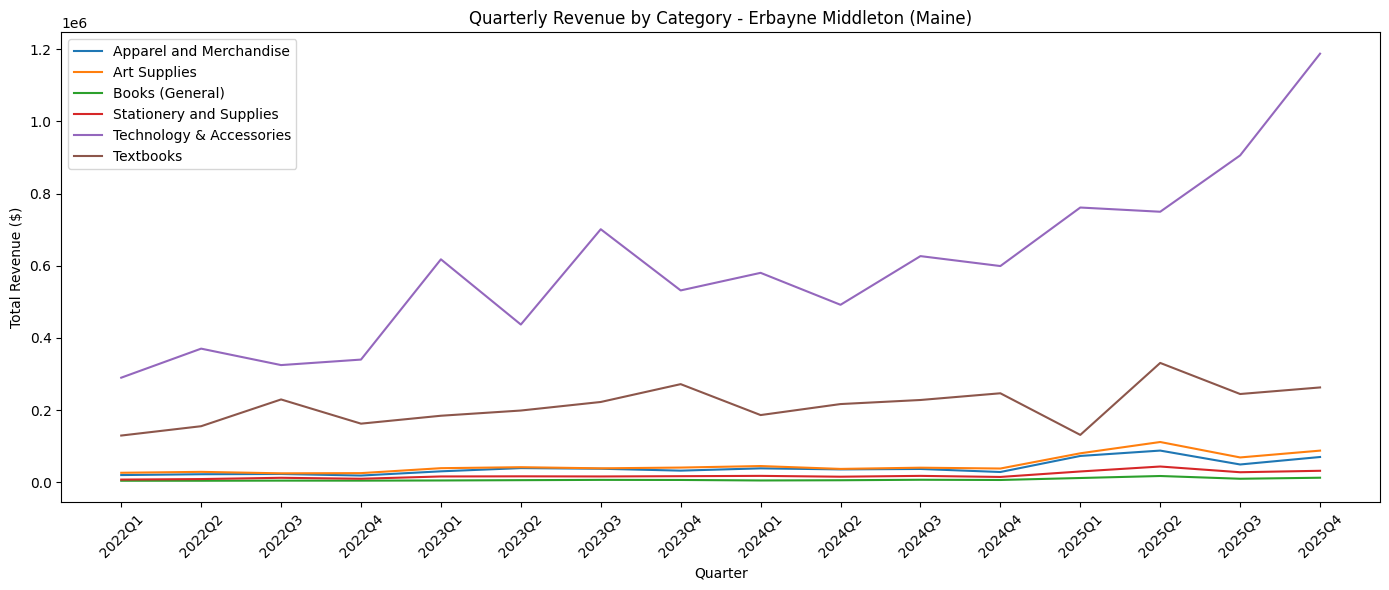

In [189]:
# Quarterly revenue by category by Erbayne on Graph
plt.figure(figsize=(14, 6))

for category in erbayne_quarterly_cat['Category'].unique():
    cat_data = erbayne_quarterly_cat[erbayne_quarterly_cat['Category'] == category]
    plt.plot(cat_data['Quarter'].astype(str), cat_data['Total Revenue'], label=category)

plt.title('Quarterly Revenue by Category - Erbayne Middleton (Maine)')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [190]:
# Quarterly revenue by category - Shruti

shruti_products['Quarter'] = shruti_products['Transaction Date'].dt.to_period('Q')

shruti_quarterly_cat = shruti_products.groupby(['Quarter', 'Category'])['Sale Amount'].sum().reset_index()
shruti_quarterly_cat.columns = ['Quarter', 'Category', 'Total Revenue']

print(shruti_quarterly_cat.to_string(index=False))

Quarter                 Category  Total Revenue
 2022Q1  Apparel and Merchandise      185908.48
 2022Q1             Art Supplies      247330.16
 2022Q1          Books (General)      107565.88
 2022Q1  Stationery and Supplies       86000.31
 2022Q1 Technology & Accessories     2724832.81
 2022Q1                Textbooks     1409407.23
 2022Q2  Apparel and Merchandise      175640.88
 2022Q2             Art Supplies      225269.77
 2022Q2          Books (General)       94440.24
 2022Q2  Stationery and Supplies       86033.86
 2022Q2 Technology & Accessories     2500843.80
 2022Q2                Textbooks     1740452.56
 2022Q3  Apparel and Merchandise      172567.28
 2022Q3             Art Supplies      215025.14
 2022Q3          Books (General)      104129.80
 2022Q3  Stationery and Supplies       88718.41
 2022Q3 Technology & Accessories     2627979.48
 2022Q3                Textbooks     1573244.42
 2022Q4  Apparel and Merchandise      195978.08
 2022Q4             Art Supplies      23

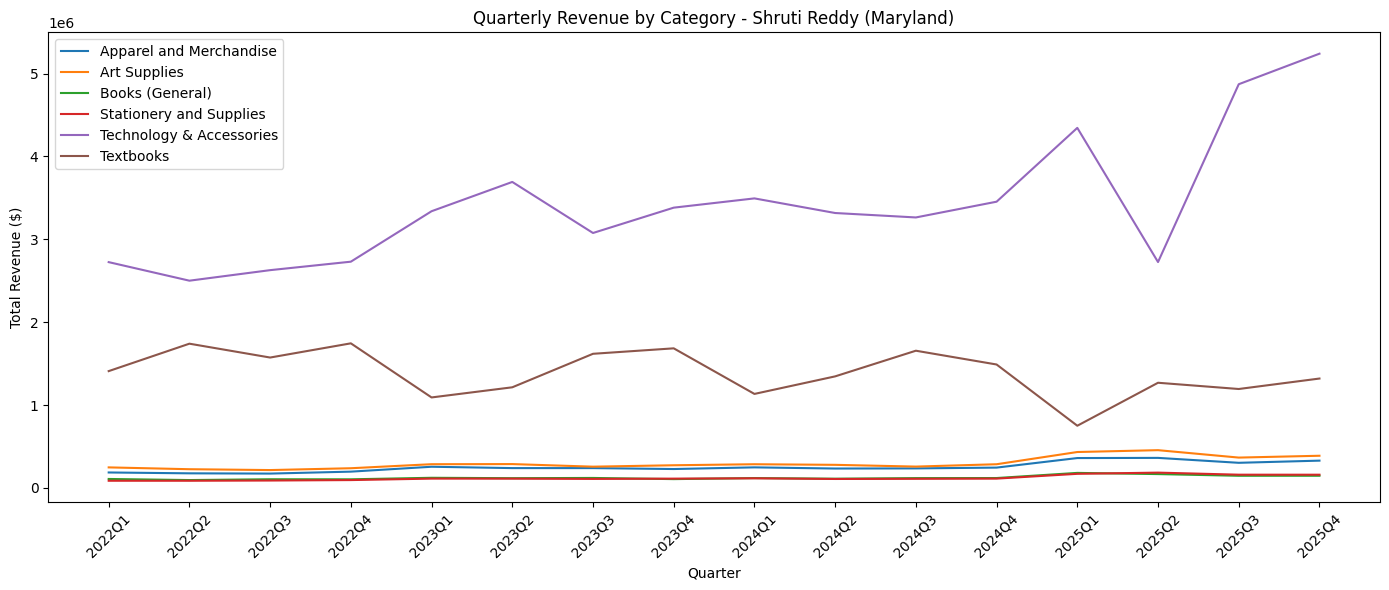

In [191]:
# Quarterly revenue by category by Shruti on Graph

plt.figure(figsize=(14, 6))

for category in shruti_quarterly_cat['Category'].unique():
    cat_data = shruti_quarterly_cat[shruti_quarterly_cat['Category'] == category]
    plt.plot(cat_data['Quarter'].astype(str), cat_data['Total Revenue'], label=category)

plt.title('Quarterly Revenue by Category - Shruti Reddy (Maryland)')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Top 2 categories in both territories are Technology & Accessories and Textbooks. 
- We see a big increase on Tech&Accs. with some dips and peaks.
- Also we observe decreasing trend in textbooks. 
- I wanted check the overall numbers country wide in these categories and how we are doing accordingly.


In [192]:
# All regions quarterly revenue all product categories.
all_products = store_sales.merge(products, on='Prod Num')
all_products = all_products.merge(product_categories[['CategoryID', 'Category']], on='CategoryID')
all_products['Transaction Date'] = pd.to_datetime(all_products['Transaction Date'])
all_products['Quarter'] = all_products['Transaction Date'].dt.to_period('Q')

# Filter for top 2 categories only
top_cats = ['Technology & Accessories', 'Textbooks']
all_quarterly_cat = all_products[all_products['Category'].isin(top_cats)].groupby(['Quarter', 'Category'])['Sale Amount'].sum().reset_index()
all_quarterly_cat.columns = ['Quarter', 'Category', 'Total Revenue']

print(all_quarterly_cat.to_string(index=False))

Quarter                 Category  Total Revenue
 2022Q1 Technology & Accessories     8921222.59
 2022Q1                Textbooks     4472307.07
 2022Q2 Technology & Accessories     9059587.04
 2022Q2                Textbooks     5395577.11
 2022Q3 Technology & Accessories     8853614.42
 2022Q3                Textbooks     5332807.26
 2022Q4 Technology & Accessories     8843585.31
 2022Q4                Textbooks     5461962.33
 2023Q1 Technology & Accessories    13644076.67
 2023Q1                Textbooks     4311379.82
 2023Q2 Technology & Accessories    13351276.19
 2023Q2                Textbooks     4916562.42
 2023Q3 Technology & Accessories    13218613.24
 2023Q3                Textbooks     6345970.62
 2023Q4 Technology & Accessories    12779229.33
 2023Q4                Textbooks     6515498.66
 2024Q1 Technology & Accessories    13603536.52
 2024Q1                Textbooks     4610000.89
 2024Q2 Technology & Accessories    12897302.74
 2024Q2                Textbooks     531

In [193]:
# Quarterly totals for Erbayne in top 2 categories
erbayne_quarterly_top = erbayne_products[erbayne_products['Category'].isin(top_cats)].groupby(['Quarter', 'Category'])['Sale Amount'].sum().reset_index()
erbayne_quarterly_top.columns = ['Quarter', 'Category', 'Total Revenue']

# Quarterly totals for Shruti - top 2 categories
shruti_quarterly_top = shruti_products[shruti_products['Category'].isin(top_cats)].groupby(['Quarter', 'Category'])['Sale Amount'].sum().reset_index()
shruti_quarterly_top.columns = ['Quarter', 'Category', 'Total Revenue']

print("Erbayne")
print(erbayne_quarterly_top.to_string(index=False))
print("Shruti")
print(shruti_quarterly_top.to_string(index=False))

Erbayne
Quarter                 Category  Total Revenue
 2022Q1 Technology & Accessories      289889.95
 2022Q1                Textbooks      129582.64
 2022Q2 Technology & Accessories      370350.68
 2022Q2                Textbooks      155445.40
 2022Q3 Technology & Accessories      324805.81
 2022Q3                Textbooks      229602.56
 2022Q4 Technology & Accessories      340035.92
 2022Q4                Textbooks      162543.37
 2023Q1 Technology & Accessories      617782.20
 2023Q1                Textbooks      184445.91
 2023Q2 Technology & Accessories      437127.53
 2023Q2                Textbooks      198890.34
 2023Q3 Technology & Accessories      701162.07
 2023Q3                Textbooks      222583.57
 2023Q4 Technology & Accessories      531641.53
 2023Q4                Textbooks      271987.54
 2024Q1 Technology & Accessories      580364.96
 2024Q1                Textbooks      186326.25
 2024Q2 Technology & Accessories      491828.40
 2024Q2                Textbooks

In [194]:
# Calculate quarterly growth rates for all regions
all_tech = all_quarterly_cat[all_quarterly_cat['Category'] == 'Technology & Accessories']['Total Revenue'].pct_change() * 100
all_text = all_quarterly_cat[all_quarterly_cat['Category'] == 'Textbooks']['Total Revenue'].pct_change() * 100

# Calculate quarterly growth rates for Erbayne
erbayne_tech = erbayne_quarterly_top[erbayne_quarterly_top['Category'] == 'Technology & Accessories']['Total Revenue'].pct_change() * 100
erbayne_text = erbayne_quarterly_top[erbayne_quarterly_top['Category'] == 'Textbooks']['Total Revenue'].pct_change() * 100

# Calculate quarterly growth rates for Shruti
shruti_tech = shruti_quarterly_top[shruti_quarterly_top['Category'] == 'Technology & Accessories']['Total Revenue'].pct_change() * 100
shruti_text = shruti_quarterly_top[shruti_quarterly_top['Category'] == 'Textbooks']['Total Revenue'].pct_change() * 100

quarters = all_quarterly_cat[all_quarterly_cat['Category'] == 'Technology & Accessories']['Quarter'].astype(str)

print("=== Tech & Accessories Quarterly Growth % ===")
print(pd.DataFrame({'Quarter': quarters.values, 'All Regions': all_tech.values, 'Erbayne': erbayne_tech.values, 'Shruti': shruti_tech.values}).to_string(index=False))

print("\n=== Textbooks Quarterly Growth % ===")
print(pd.DataFrame({'Quarter': quarters.values, 'All Regions': all_text.values, 'Erbayne': erbayne_text.values, 'Shruti': shruti_text.values}).to_string(index=False))

=== Tech & Accessories Quarterly Growth % ===
Quarter  All Regions    Erbayne     Shruti
 2022Q1          NaN        NaN        NaN
 2022Q2     1.550958  27.755612  -8.220285
 2022Q3    -2.273532 -12.297769   5.083711
 2022Q4    -0.113277   4.688989   3.889210
 2023Q1    54.282185  81.681453  22.307789
 2023Q2    -2.145990 -29.242453  10.584954
 2023Q3    -0.993635  60.402176 -16.686184
 2023Q4    -3.323979 -24.177084   9.938332
 2024Q1     6.450367   9.164715   3.305736
 2024Q2    -5.191545 -15.255325  -5.049229
 2024Q3     2.744238  27.420781  -1.614706
 2024Q4     1.088527  -4.390222   5.826624
 2025Q1    44.080519  27.057995  25.793518
 2025Q2   -23.675949  -1.534585 -37.270072
 2025Q3    47.581300  20.825764  78.743732
 2025Q4    17.987213  31.109878   7.565012

=== Textbooks Quarterly Growth % ===
Quarter  All Regions    Erbayne     Shruti
 2022Q1          NaN        NaN        NaN
 2022Q2    20.644156  19.958507  23.488267
 2022Q3    -1.163357  47.706243  -9.607164
 2022Q4     2

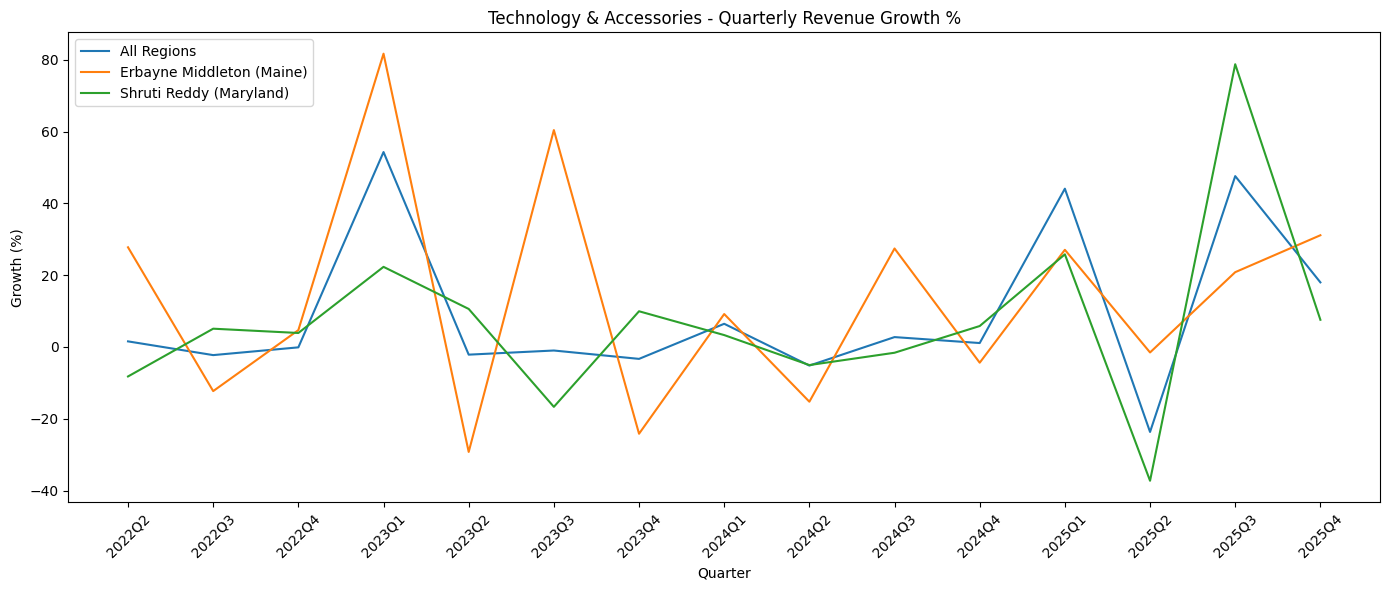

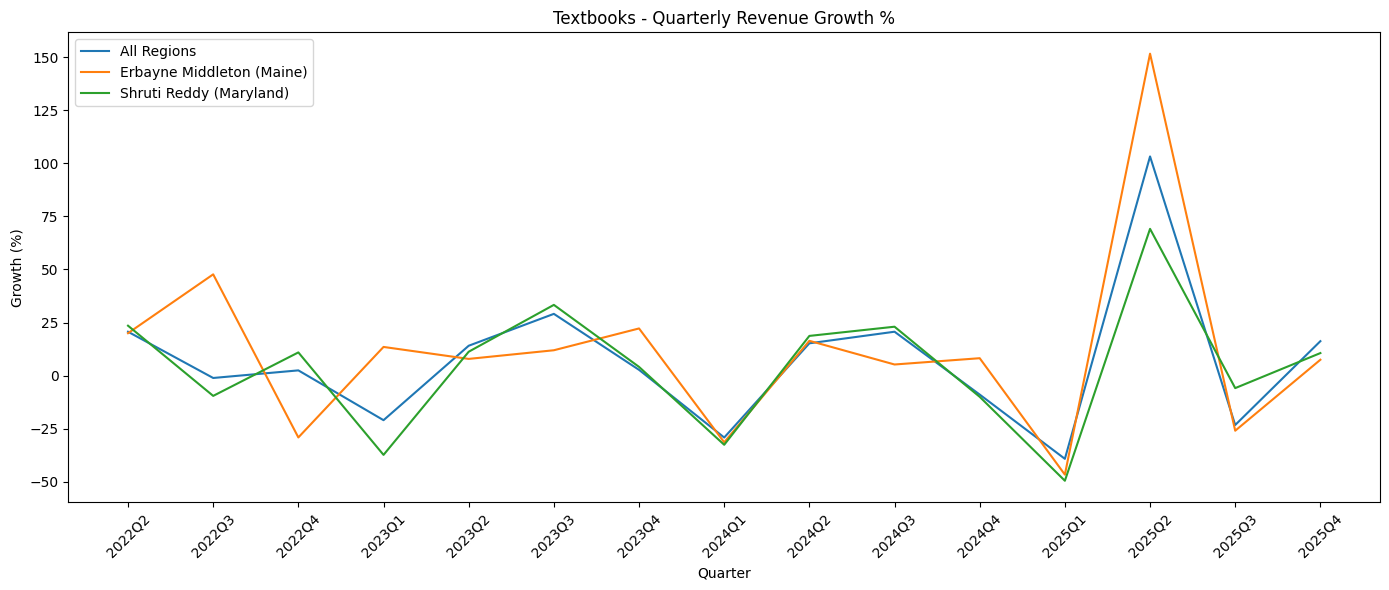

In [195]:
quarters_list = all_quarterly_cat[all_quarterly_cat['Category'] == 'Technology & Accessories']['Quarter'].astype(str).values[1:]

# Tech & Accessories growth chart
plt.figure(figsize=(14, 6))
plt.plot(quarters_list, all_tech.dropna().values, label='All Regions')
plt.plot(quarters_list, erbayne_tech.dropna().values, label='Erbayne Middleton (Maine)')
plt.plot(quarters_list, shruti_tech.dropna().values, label='Shruti Reddy (Maryland)')
plt.title('Technology & Accessories - Quarterly Revenue Growth %')
plt.xlabel('Quarter')
plt.ylabel('Growth (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Textbooks growth chart
plt.figure(figsize=(14, 6))
plt.plot(quarters_list, all_text.dropna().values, label='All Regions')
plt.plot(quarters_list, erbayne_text.dropna().values, label='Erbayne Middleton (Maine)')
plt.plot(quarters_list, shruti_text.dropna().values, label='Shruti Reddy (Maryland)')
plt.title('Textbooks - Quarterly Revenue Growth %')
plt.xlabel('Quarter')
plt.ylabel('Growth (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()